In [23]:
!pip install -q segmentation-models-pytorch==0.3.4 albumentations==1.4.3

In [24]:
import kagglehub
briscdataset_brisc2025_path = kagglehub.dataset_download('briscdataset/brisc2025')
print('Data source import complete.')

Data source import complete.


In [25]:
import os, glob, random, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cuda


In [26]:
DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025"

for root, dirs, files in os.walk(DATA_ROOT):
    level  = root.replace(DATA_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files)[:5]:
        print(f"{indent}  {f}")
    if len(files) > 5:
        print(f"{indent}  ... ({len(files)} files total)")

DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"

CLS_TRAIN_DIR  = os.path.join(DATA_ROOT, "classification_task", "train")
CLS_TEST_DIR   = os.path.join(DATA_ROOT, "classification_task", "test")
SEG_TRAIN_IMG  = os.path.join(DATA_ROOT, "segmentation_task", "train", "images")
SEG_TRAIN_MASK = os.path.join(DATA_ROOT, "segmentation_task", "train", "masks")
SEG_TEST_IMG   = os.path.join(DATA_ROOT, "segmentation_task", "test",  "images")
SEG_TEST_MASK  = os.path.join(DATA_ROOT, "segmentation_task", "test",  "masks")

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SIZE     = 224

def build_cls_df(root_dir):
    rows = []
    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            print(f"  WARNING: missing folder {cls_dir}")
            continue
        for fpath in glob.glob(os.path.join(cls_dir, "*.jpg")):
            rows.append({"filepath": fpath, "label": CLASS_TO_IDX[cls_name]})
    return pd.DataFrame(rows)

cls_train_df = build_cls_df(CLS_TRAIN_DIR)
cls_test_df  = build_cls_df(CLS_TEST_DIR)
print("Classification train:", len(cls_train_df))
print("Classification test: ", len(cls_test_df))

def build_seg_df(img_dir, mask_dir):
    rows = []
    for img_path in sorted(glob.glob(os.path.join(img_dir, "*.jpg"))):
        stem      = os.path.splitext(os.path.basename(img_path))[0]
        mask_path = os.path.join(mask_dir, stem + ".png")
        if os.path.exists(mask_path):
            rows.append({"img_path": img_path, "mask_path": mask_path})
        else:
            print(f"  WARNING: no mask for {stem}")
    return pd.DataFrame(rows)

seg_train_df = build_seg_df(SEG_TRAIN_IMG, SEG_TRAIN_MASK)
seg_test_df  = build_seg_df(SEG_TEST_IMG,  SEG_TEST_MASK)
print("\nSegmentation train:", len(seg_train_df))
print("Segmentation test: ", len(seg_test_df))

brisc2025/
  brisc2025/
    README.md
    manifest.csv
    manifest.csv.sha256
    manifest.json
    manifest.json.sha256
    segmentation_task/
      test/
        images/
          brisc2025_test_00001_gl_ax_t1.jpg
          brisc2025_test_00002_gl_ax_t1.jpg
          brisc2025_test_00003_gl_ax_t1.jpg
          brisc2025_test_00004_gl_ax_t1.jpg
          brisc2025_test_00005_gl_ax_t1.jpg
          ... (860 files total)
        masks/
          brisc2025_test_00001_gl_ax_t1.png
          brisc2025_test_00002_gl_ax_t1.png
          brisc2025_test_00003_gl_ax_t1.png
          brisc2025_test_00004_gl_ax_t1.png
          brisc2025_test_00005_gl_ax_t1.png
          ... (860 files total)
      train/
        images/
          brisc2025_train_00001_gl_ax_t1.jpg
          brisc2025_train_00002_gl_ax_t1.jpg
          brisc2025_train_00003_gl_ax_t1.jpg
          brisc2025_train_00004_gl_ax_t1.jpg
          brisc2025_train_00005_gl_ax_t1.jpg
          ... (3933 files total)
        masks/
      

In [27]:
train_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

test_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

In [28]:
class BrainClassDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, int(row["label"])


class BrainSegDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        img  = cv2.imread(row["img_path"])
        img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.uint8)
        if self.transform:
            aug       = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        return img, mask.long()

In [29]:
cls_train_ds = BrainClassDataset(cls_train_df, train_aug)
cls_test_ds  = BrainClassDataset(cls_test_df,  test_aug)
cls_train_dl = DataLoader(cls_train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
cls_test_dl  = DataLoader(cls_test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

seg_train_ds = BrainSegDataset(seg_train_df, train_aug)
seg_test_ds  = BrainSegDataset(seg_test_df,  test_aug)
seg_train_dl = DataLoader(seg_train_ds, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
seg_test_dl  = DataLoader(seg_test_ds,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f"Cls — train: {len(cls_train_ds):,}  test: {len(cls_test_ds):,}")
print(f"Seg — train: {len(seg_train_ds):,}  test: {len(seg_test_ds):,}")

Cls — train: 5,000  test: 1,000
Seg — train: 3,933  test: 860


In [30]:
# ── Classification builders ───────────────────────────────────

def build_efficientnet_b0():
    m = models.efficientnet_b0(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True),
                                  nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_b1():
    m = models.efficientnet_b1(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True),
                                  nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_b3():
    m = models.efficientnet_b3(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True),
                                  nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_efficientnet_v2_s():
    m = models.efficientnet_v2_s(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(nn.Dropout(0.3, inplace=True),
                                  nn.Linear(m.classifier[1].in_features, NUM_CLASSES))
    return m

def build_resnet50():
    m = models.resnet50(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, NUM_CLASSES)
    return m

def build_mobilenet_v3():
    m = models.mobilenet_v3_small(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def build_vgg16():
    m = models.vgg16_bn(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

def build_convnext_tiny():
    m = models.convnext_tiny(weights="IMAGENET1K_V1")
    m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, NUM_CLASSES)
    return m

CLS_REGISTRY = {
    "EfficientNet-B0":  build_efficientnet_b0,
    "EfficientNet-B1":  build_efficientnet_b1,
    "EfficientNet-B3":  build_efficientnet_b3,
    "EfficientNetV2-S": build_efficientnet_v2_s,
    "ResNet-50":        build_resnet50,
    "MobileNet-V3-S":   build_mobilenet_v3,
    "VGG-16-BN":        build_vgg16,
    "ConvNeXt-Tiny":    build_convnext_tiny,
}

# ── Segmentation: (smp_class, encoder_name) ──────────────────
SEG_REGISTRY = {
    "UNet-EffB0":          (smp.Unet,          "efficientnet-b0"),
    "UNet-ResNet34":       (smp.Unet,          "resnet34"),
    "UNetPP-EffB0":        (smp.UnetPlusPlus,  "efficientnet-b0"),
    "UNetPP-ResNet34":     (smp.UnetPlusPlus,  "resnet34"),
    "DeepLabV3P-EffB0":    (smp.DeepLabV3Plus, "efficientnet-b0"),
    "DeepLabV3P-ResNet50": (smp.DeepLabV3Plus, "resnet50"),
    "FPN-EffB0":           (smp.FPN,           "efficientnet-b0"),
    "MAnet-EffB0":         (smp.MAnet,         "efficientnet-b0"),
}

print("CLS models:", list(CLS_REGISTRY.keys()))
print("SEG models:", list(SEG_REGISTRY.keys()))

CLS models: ['EfficientNet-B0', 'EfficientNet-B1', 'EfficientNet-B3', 'EfficientNetV2-S', 'ResNet-50', 'MobileNet-V3-S', 'VGG-16-BN', 'ConvNeXt-Tiny']
SEG models: ['UNet-EffB0', 'UNet-ResNet34', 'UNetPP-EffB0', 'UNetPP-ResNet34', 'DeepLabV3P-EffB0', 'DeepLabV3P-ResNet50', 'FPN-EffB0', 'MAnet-EffB0']


In [31]:
# ============================================================
#  ONLY EDIT THIS CELL
#  Pick one name from each registry printed above
# ============================================================
CLS_MODEL_NAME = "EfficientNet-B3"
SEG_MODEL_NAME = "UNet-EffB0"

LR           = 1e-4
WEIGHT_DECAY = 1e-4
CLS_EPOCHS   = 15
SEG_EPOCHS   = 1


In [32]:
cls_criterion = nn.CrossEntropyLoss()

bce_loss  = nn.BCEWithLogitsLoss()
dice_loss = smp.losses.DiceLoss(mode="binary")

def seg_criterion(pred, target):
    target_f = target.float().unsqueeze(1)
    return 0.5 * bce_loss(pred, target_f) + 0.5 * dice_loss(pred, target_f)

def dice_score(pred_logits, target):
    pred  = (torch.sigmoid(pred_logits) > 0.5).float()
    tgt   = target.float().unsqueeze(1)
    inter = (pred * tgt).sum(dim=(2, 3))
    union = pred.sum(dim=(2, 3)) + tgt.sum(dim=(2, 3))
    return ((2 * inter + 1e-6) / (union + 1e-6)).mean().item()

@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    correct = n = 0
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        n       += imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    acc = correct / n
    f1  = f1_score(all_labels, all_preds, average="weighted")
    return acc, f1, all_preds, all_labels

def train_one_epoch_seg(model, loader, optimizer):
    model.train()
    total_loss = total_dice = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        pred = model(imgs)
        loss = seg_criterion(pred, masks)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        total_dice += dice_score(pred, masks) * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n

def train_one_epoch_cls(model, loader, optimizer):
    model.train()
    total_loss = correct = n = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = cls_criterion(out, labels)
        loss.backward(); optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (out.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n

@torch.no_grad()
def eval_seg(model, loader):
    model.eval()
    total_loss = total_dice = n = 0
    for imgs, masks in loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        pred = model(imgs)
        total_loss += seg_criterion(pred, masks).item() * imgs.size(0)
        total_dice += dice_score(pred, masks) * imgs.size(0)
        n          += imgs.size(0)
    return total_loss / n, total_dice / n

print("Helpers ready.")


Helpers ready.


In [33]:
cls_model     = CLS_REGISTRY[CLS_MODEL_NAME]().to(DEVICE)
cls_optimizer = torch.optim.AdamW(cls_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

cls_history  = {"train_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
best_val_acc = 0.0

for epoch in range(1, CLS_EPOCHS + 1):
    tr_loss, tr_acc           = train_one_epoch_cls(cls_model, cls_train_dl, cls_optimizer)
    val_acc, val_f1, _, _     = eval_cls(cls_model, cls_test_dl)

    cls_history["train_loss"].append(tr_loss)
    cls_history["train_acc"].append(tr_acc)
    cls_history["val_acc"].append(val_acc)
    cls_history["val_f1"].append(val_f1)

    flag = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(cls_model.state_dict(), f"best_cls_{CLS_MODEL_NAME}.pth")
        flag = " ✓"

    print(f"[{CLS_MODEL_NAME}] {epoch:02d}/{CLS_EPOCHS}  "
          f"loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}  "
          f"val_acc={val_acc:.4f}  val_f1={val_f1:.4f}{flag}")

print(f"\nBest val acc: {best_val_acc:.4f}")


[EfficientNet-B3] 01/15  loss=0.6378  tr_acc=0.7728  val_acc=0.9120  val_f1=0.9112 ✓
[EfficientNet-B3] 02/15  loss=0.2174  tr_acc=0.9264  val_acc=0.9700  val_f1=0.9700 ✓
[EfficientNet-B3] 03/15  loss=0.1340  tr_acc=0.9534  val_acc=0.9800  val_f1=0.9799 ✓
[EfficientNet-B3] 04/15  loss=0.1054  tr_acc=0.9616  val_acc=0.9830  val_f1=0.9830 ✓
[EfficientNet-B3] 05/15  loss=0.0728  tr_acc=0.9750  val_acc=0.9840  val_f1=0.9839 ✓
[EfficientNet-B3] 06/15  loss=0.0694  tr_acc=0.9766  val_acc=0.9900  val_f1=0.9900 ✓
[EfficientNet-B3] 07/15  loss=0.0676  tr_acc=0.9770  val_acc=0.9930  val_f1=0.9930 ✓
[EfficientNet-B3] 08/15  loss=0.0479  tr_acc=0.9842  val_acc=0.9940  val_f1=0.9940 ✓
[EfficientNet-B3] 09/15  loss=0.0416  tr_acc=0.9872  val_acc=0.9960  val_f1=0.9960 ✓
[EfficientNet-B3] 10/15  loss=0.0404  tr_acc=0.9862  val_acc=0.9960  val_f1=0.9960
[EfficientNet-B3] 11/15  loss=0.0270  tr_acc=0.9910  val_acc=0.9910  val_f1=0.9910
[EfficientNet-B3] 12/15  loss=0.0230  tr_acc=0.9928  val_acc=0.9930  

In [34]:
arch, encoder = SEG_REGISTRY[SEG_MODEL_NAME]
seg_model     = arch(encoder_name=encoder, encoder_weights="imagenet",
                     in_channels=3, classes=1, activation=None).to(DEVICE)
seg_optimizer = torch.optim.AdamW(seg_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

seg_history   = {"train_loss": [], "val_loss": [], "train_dice": [], "val_dice": []}
best_val_dice = 0.0

for epoch in range(1, SEG_EPOCHS + 1):
    tr_loss, tr_dice = train_one_epoch_seg(seg_model, seg_train_dl, seg_optimizer)
    vl_loss, vl_dice = eval_seg(seg_model, seg_test_dl)

    seg_history["train_loss"].append(tr_loss)
    seg_history["val_loss"].append(vl_loss)
    seg_history["train_dice"].append(tr_dice)
    seg_history["val_dice"].append(vl_dice)

    flag = ""
    if vl_dice > best_val_dice:
        best_val_dice = vl_dice
        torch.save(seg_model.state_dict(), f"best_seg_{SEG_MODEL_NAME}.pth")
        flag = " ✓"

    print(f"[{SEG_MODEL_NAME}] {epoch:02d}/{SEG_EPOCHS}  "
          f"tr_loss={tr_loss:.4f}  tr_dice={tr_dice:.4f}  "
          f"vl_loss={vl_loss:.4f}  vl_dice={vl_dice:.4f}{flag}")

print(f"\nBest val Dice: {best_val_dice:.4f}")

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 179MB/s]


[UNet-EffB0] 01/1  tr_loss=0.5185  tr_dice=0.4722  vl_loss=0.3933  vl_dice=0.6414 ✓

Best val Dice: 0.6414


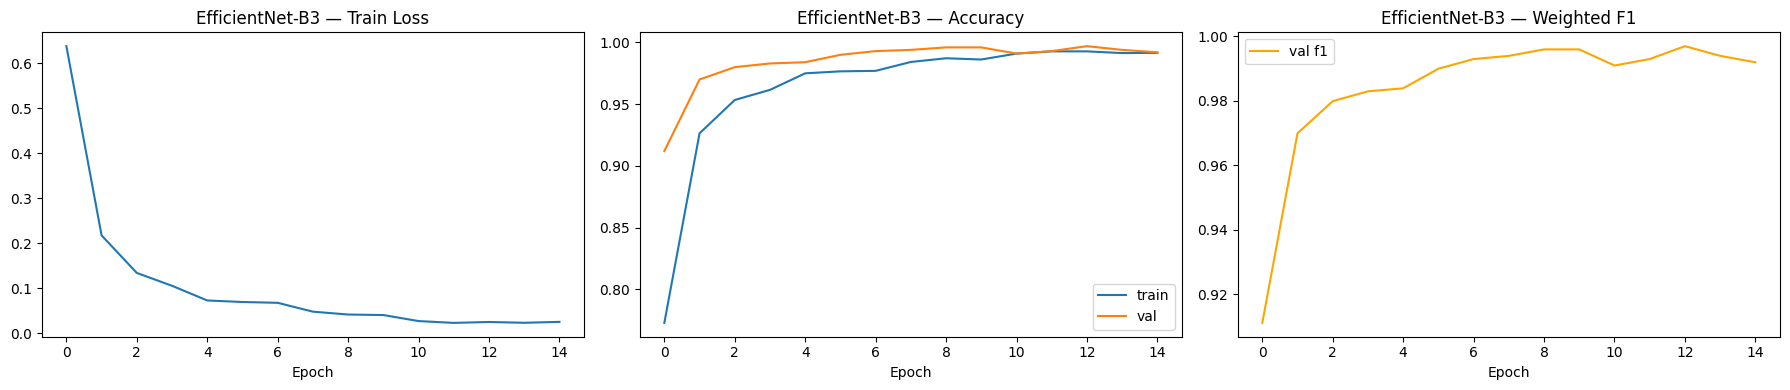


EfficientNet-B3  |  Test accuracy: 0.9970  |  Weighted F1: 0.9970

              precision    recall  f1-score   support

      glioma       1.00      1.00      1.00       254
  meningioma       1.00      1.00      1.00       306
    no_tumor       1.00      1.00      1.00       140
   pituitary       1.00      1.00      1.00       300

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



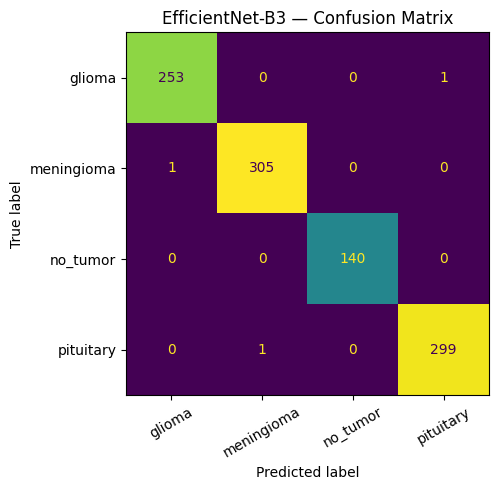

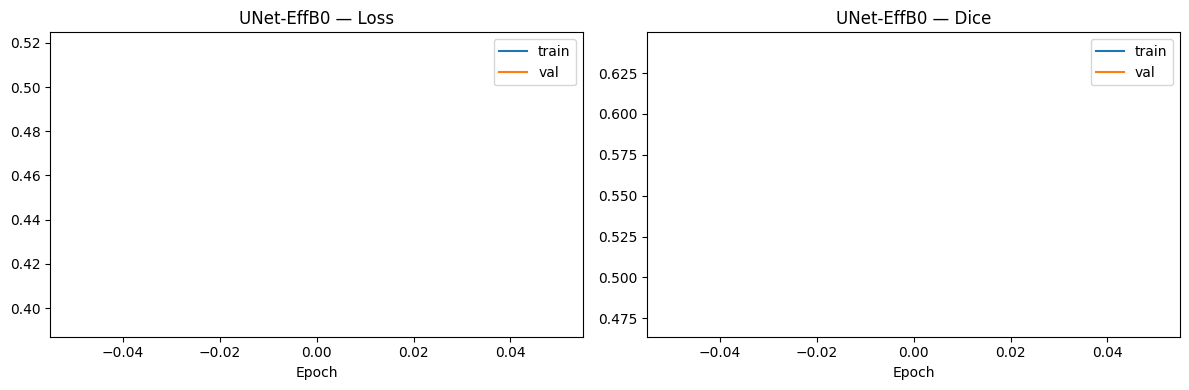

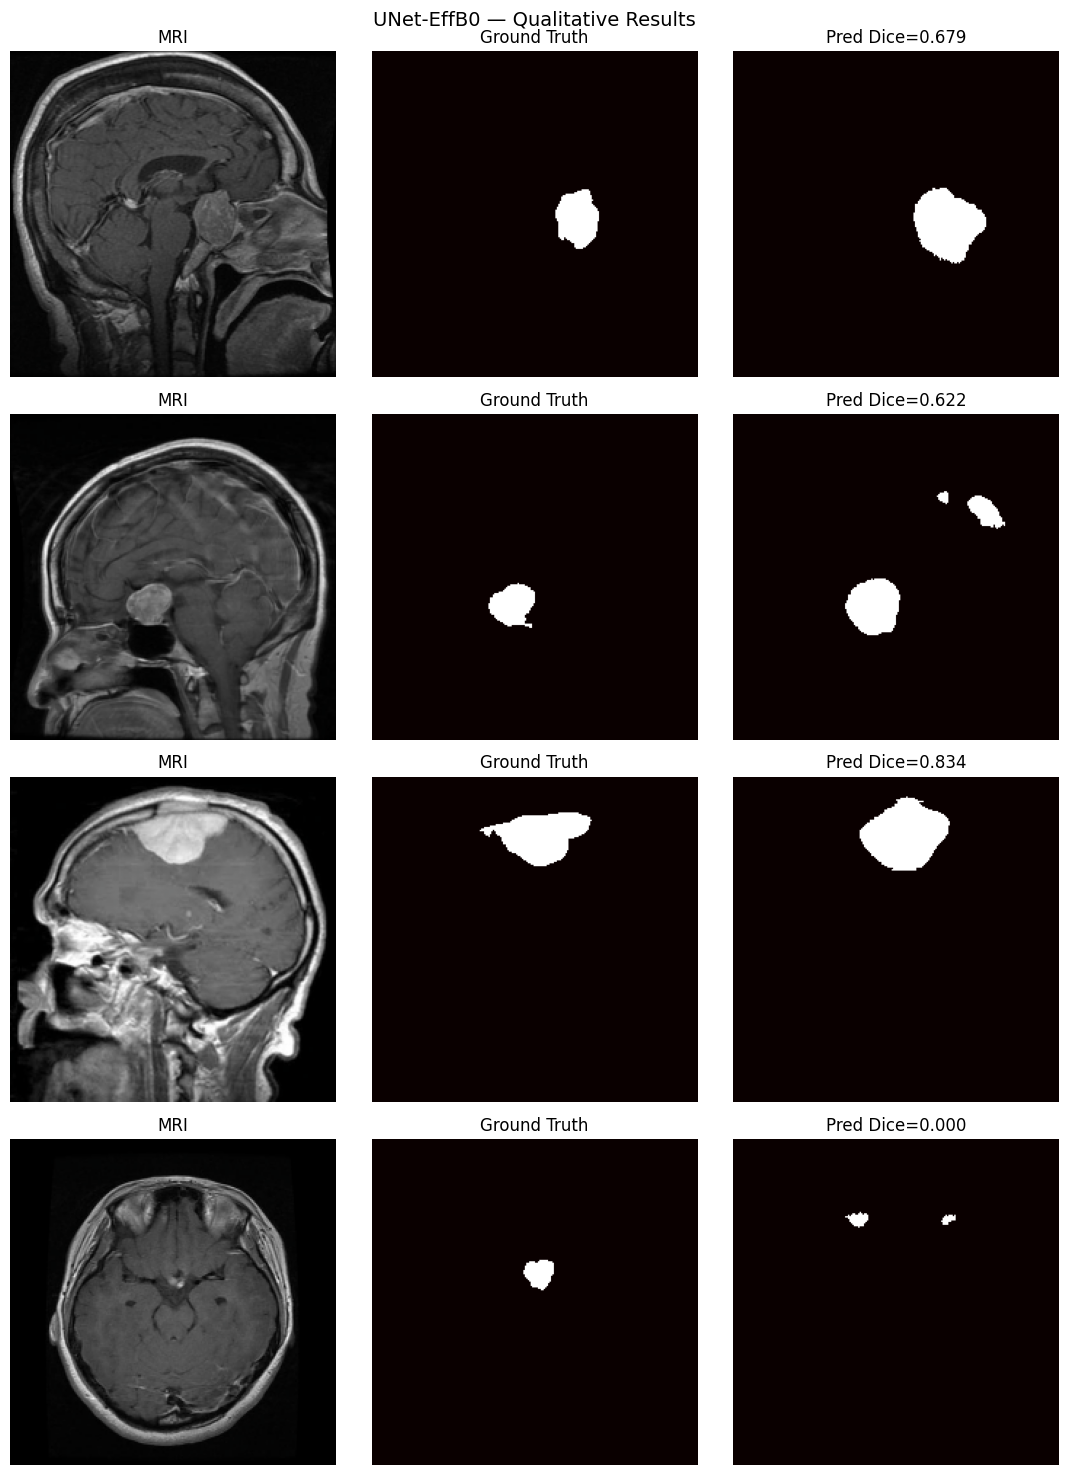

✅ Done.


In [35]:
# ── Classification curves ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(cls_history["train_loss"])
axes[0].set_title(f"{CLS_MODEL_NAME} — Train Loss"); axes[0].set_xlabel("Epoch")

axes[1].plot(cls_history["train_acc"], label="train")
axes[1].plot(cls_history["val_acc"],   label="val")
axes[1].set_title(f"{CLS_MODEL_NAME} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(cls_history["val_f1"], label="val f1", color="orange")
axes[2].set_title(f"{CLS_MODEL_NAME} — Weighted F1"); axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.tight_layout(); plt.savefig(f"cls_curves_{CLS_MODEL_NAME}.png", dpi=150); plt.show()

# ── Classification report + confusion matrix ──────────────────
cls_model.load_state_dict(torch.load(f"best_cls_{CLS_MODEL_NAME}.pth"))
val_acc, val_f1, preds, labels_ = eval_cls(cls_model, cls_test_dl)
print(f"\n{CLS_MODEL_NAME}  |  Test accuracy: {val_acc:.4f}  |  Weighted F1: {val_f1:.4f}\n")
print(classification_report(labels_, preds, target_names=CLASS_NAMES))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(labels_, preds), display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, xticks_rotation=30)
ax.set_title(f"{CLS_MODEL_NAME} — Confusion Matrix")
plt.tight_layout(); plt.savefig(f"cls_cm_{CLS_MODEL_NAME}.png", dpi=150); plt.show()

# ── Segmentation curves ───────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(seg_history["train_loss"], label="train")
ax1.plot(seg_history["val_loss"],   label="val")
ax1.set_title(f"{SEG_MODEL_NAME} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
ax2.plot(seg_history["train_dice"], label="train")
ax2.plot(seg_history["val_dice"],   label="val")
ax2.set_title(f"{SEG_MODEL_NAME} — Dice"); ax2.set_xlabel("Epoch"); ax2.legend()
plt.tight_layout(); plt.savefig(f"seg_curves_{SEG_MODEL_NAME}.png", dpi=150); plt.show()

# ── Segmentation qualitative spot-check ──────────────────────
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

seg_model.load_state_dict(torch.load(f"best_seg_{SEG_MODEL_NAME}.pth"))
sample_ds = BrainSegDataset(seg_test_df.sample(4, random_state=7).reset_index(drop=True), test_aug)

seg_model.eval()
fig, axes = plt.subplots(4, 3, figsize=(11, 15))
with torch.no_grad():
    for i in range(4):
        img_t, mask_t = sample_ds[i]
        pred   = torch.sigmoid(seg_model(img_t.unsqueeze(0).to(DEVICE))).squeeze().cpu().numpy()
        img_np = (img_t.permute(1, 2, 0).numpy() * STD + MEAN).clip(0, 1)
        dice   = (2 * ((pred > 0.5) * mask_t.numpy()).sum() + 1e-6) / \
                 ((pred > 0.5).sum() + mask_t.numpy().sum() + 1e-6)
        axes[i, 0].imshow(img_np);                     axes[i, 0].set_title("MRI")
        axes[i, 1].imshow(mask_t.numpy(), cmap="hot"); axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(pred > 0.5,     cmap="hot"); axes[i, 2].set_title(f"Pred Dice={dice:.3f}")
        for ax in axes[i]: ax.axis("off")

plt.suptitle(f"{SEG_MODEL_NAME} — Qualitative Results", fontsize=14)
plt.tight_layout(); plt.savefig(f"seg_qual_{SEG_MODEL_NAME}.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Done.")
